<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

## Нижанковский Артём Дмитриевич


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

В реальных сценариях модели часто доступны только через API: например, сервис классификации изображений, антивирус, система обнаружения вторжений. Мы можем послать вход и получить ответ, но не знаем весов модели. Атаки в белом ящике (FGSM, PGD, C&W) требуют градиентов, и в чёрном ящике напрямую неприменимы. Значит, нужно либо восстанавливать градиенты через запросы, либо работать без них вообще.

Transfer-based. У нас нет доступа к модели-жертве вообще (или почти нет). Мы строим свою модель (суррогат) на данных того же домена, атакуем её белоящично и надеемся, что примеры перенесутся на цель.

Score-based. API возвращает вероятности классов. Мы можем оценивать градиент через конечные разности или через случайные направления, тратя запросы.

Decision-based. API возвращает только метку класса. Градиент оценить нельзя, но можно исследовать границу решения и двигаться вдоль неё.

## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader, pandas, time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import time
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")


Устройство: cpu


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

В реальном сценарии каждый запрос к API стоит денег или времени, и их число часто ограничено. Прямой вызов model(x) в коде атаки обошёл бы счётчик, и мы бы не знали реальную стоимость атаки. Оборачивание делает подсчёт автоматическим и честным.
QueryCounter  считает запросы и предоставляет три уровня доступа: логиты, вероятности, метку. Все последующие атаки обязаны обращаться к модели только через оракул, чтобы корректно измерять стоимость атаки в запросах.

In [ ]:
# TODO: загрузите FashionMNIST через torchvision.datasets, создайте train_loader и test_loader
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 310kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]


In [ ]:
class TargetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Первый свёрточный блок: 1 → 32 карты
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Второй свёрточный блок: 32 → 64 карты
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [ ]:
# TODO: обучите target_model на train_loader (2-3 эпохи)

def train_epoch(model, loader, optimizer, criterion, device):
    # Одна эпоха обучения
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def evaluate_accuracy(model, loader, device):
    # Точность на чистых данных
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# Обучаем целевую модель
target_model = TargetCNN().to(device)
optimizer = torch.optim.Adam(target_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(4):
    loss, acc = train_epoch(target_model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")

# TODO: оцените clean accuracy на тестовой выборке
clean_accuracy = evaluate_accuracy(target_model, test_loader, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Epoch 1: loss=0.5185, acc=0.8129
Epoch 2: loss=0.3308, acc=0.8798
Epoch 3: loss=0.2821, acc=0.8958
Epoch 4: loss=0.2521, acc=0.9064
Clean accuracy: 0.8973


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [ ]:
# TODO: реализуйте класс QueryCounter
class QueryCounter:
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        # Сбрасываем счётчик перед новой атакой
        self.n_queries = 0

    def logits(self, x):
        # Полные логиты. Счётчик растёт на размер батча.
        self.n_queries += x.size(0)
        self.model.eval()
        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        # Вероятности — softmax от логитов
        logits = self.logits(x)
        return F.softmax(logits, dim=1)

    def label(self, x):
        # Только предсказанный класс
        logits = self.logits(x)
        return logits.argmax(dim=1)

# Создаём оракул один раз — все атаки будут работать через него
oracle = QueryCounter(target_model)

## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

Это формула **якобиан-аугментации** из метода Papernot et al. — способа расширить обучающий набор для суррогатной модели.

$S_{\rho+1}$ — новый набор данных на следующем раунде.

**Справа** объединение двух множеств:

1. **$\{\tilde{x} + \lambda \cdot \text{sign}(J_F[\tilde{O}(\tilde{x})]) : \tilde{x} \in S_\rho\}$** — сгенерированные новые примеры.
2. **$S_\rho$** — старый набор, который мы сохраняем.

- $\tilde{x}$ — пример из текущего набора $S_\rho$
- $\tilde{O}(\tilde{x})$ — метка, которую оракул (целевая модель) дал этому примеру
- $J_F[\tilde{O}(\tilde{x})]$ — якобиан суррогатной модели $F$ по входу, посчитанный для этой метки. Проще говоря — **градиент лосса по пикселям**
- $\text{sign}(\cdot)$ — берём только знак: +1 или −1 для каждого пикселя
- $\lambda$ — размер шага (обычно 0.05–0.1)

Т.е. берём каждый пример из текущего набора. Спрашиваем у суррогата: «в какую сторону нужно сдвинуть пиксели, чтобы ты сильнее ошибся?» — это и есть градиент. Делаем маленький шаг в этом направлении (по знаку, то есть на фиксированную величину $\lambda$ в каждую сторону). Получаем новый пример, который для суррогата «труднее».

Мы хотим, чтобы суррогат был похож на цель **не только на обычных примерах**, но и в тех точках, где он неуверен — то есть рядом с границей решения. Новые примеры генерируются именно в таких местах, поэтому обучение на них делает суррогат более точным имитатором цели.

**Почему объединение с $S_\rho$:** мы не заменяем старый набор, а добавляем к нему. Набор растёт с каждым раундом (в коде удваивается: 200 → 400 → 800 → ...). Это позволяет модели не забывать старые примеры.

Новые примеры $\tilde{x} + \lambda \cdot \text{sign}(\ldots)$ размечаются через оракул (`oracle.label`), и весь расширенный набор идёт на следующее дообучение суррогата.

In [ ]:
# TODO: реализуйте класс SubstituteMLP — архитектура должна отличаться от TargetCNN
class SubstituteMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

Оракул - свёрточная. 2 свёрточных слоя, 2 полносвязных, пуллинг. Обрабатывает изображение как картинку: свёртки скользят по пространственным окнам 3×3, ищут локальные паттерны (края, углы, текстуры). MaxPooling уменьшает размерность, сохраняя пространственную структуру.  

Суррогат - полносвязная, 2 полносвязных слоя. Обрабатывает изображение как плоский вектор из 784 чисел. Сразу после Flatten каждый пиксель — это отдельный признак, никакой связи с соседями нет.

In [ ]:
# TODO: соберите начальный набор данных (n_seed_per_class примеров на класс из train_dataset,
# ИСПОЛЬЗУЯ ТОЛЬКО ИЗОБРАЖЕНИЯ, метки получите через oracle.label)

oracle.reset()
n_seed_per_class = 20

# Фиксируем seed для воспроизводимости случайного отбора
torch.manual_seed(RANDOM_STATE)

# Собираем по 20 СЛУЧАЙНЫХ изображений на каждый класс из train_dataset.
# Истинные метки используются ТОЛЬКО для балансировки набора по классам,
# а не как целевые метки для обучения суррогата.
seed_images = []
for c in range(10):
    # Находим все индексы примеров с истинной меткой c
    indices = [i for i, (_, y) in enumerate(train_dataset) if y == c]

    # Выбираем 20 случайных индексов из найденных (вместо первых 20)
    chosen = torch.randperm(len(indices))[:n_seed_per_class]

    # Достаём изображения по выбранным индексам
    # ВАЖНО: саму метку из датасета игнорируем — берём только картинку
    for j in chosen:
        img, _ = train_dataset[indices[j.item()]]
        seed_images.append(img)

# Складываем в один тензор и отправляем на устройство
substitute_data = torch.stack(seed_images).to(device)

# Метки получаем ТОЛЬКО через оракул — истинные метки игнорируем
with torch.no_grad():
    oracle_labels = oracle.label(substitute_data)

print(f"Начальный набор: {substitute_data.size(0)} примеров")
print(f"Запросов к оракулу: {oracle.n_queries}")

Начальный набор: 200 примеров
Запросов к оракулу: 200


**$\{\tilde{x} + \lambda \cdot \text{sign}(J_F[\tilde{O}(\tilde{x})]) : \tilde{x} \in S_\rho\}$**

In [ ]:
# TODO: реализуйте функцию якобиан-аугментации

def jacobian_augmentation(model, x, labels, lam=0.1):
    # x — копия с градиентом по входу
    x = x.clone().detach().requires_grad_(True)
    model.eval()

    # Считаем лосс и берём градиент по входу
    logits = model(x)
    loss = F.cross_entropy(logits, labels)
    grad = torch.autograd.grad(loss, x)[0]

    # Новый пример: сдвиг по знаку градиента
    x_new = x + lam * grad.sign()
    # Ограничиваем пиксели [0, 1]
    return torch.clamp(x_new, 0, 1).detach()

In [ ]:
# TODO: реализуйте цикл из n_rounds раундов:
# на каждом раунде — дообучение суррогата на current_data/current_labels,
# затем якобиан-аугментация и разметка новых примеров через oracle.label
substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=0.001)
n_rounds = 6

current_data = substitute_data.clone() # 200 картинок
current_labels = oracle_labels.clone() # 200 меток от оракула

for round_idx in range(n_rounds):
    # Дообучаем суррогат на метках оракула, а не на истинных метках FashionMNIST (250 шагов SGD)
    substitute_model.train()
    for _ in range(250):
        idx = torch.randperm(current_data.size(0))[:128]
        xb = current_data[idx]
        yb = current_labels[idx]
        opt_sub.zero_grad()
        loss = F.cross_entropy(substitute_model(xb), yb)
        loss.backward()
        opt_sub.step()

    # Якобиан-аугментация:
    # Берём весь текущий набор current_data
    # Для каждого примера считаем градиент лосса по входу (через суррогат)
    # Сдвигаем пример, gолучаем столько же новых примеров, сколько было в current_data
    new_data = jacobian_augmentation(substitute_model, current_data, current_labels, lam=0.05)

    # Спрашиваем у оракула метки для новых примеров
    with torch.no_grad():
        new_labels = oracle.label(new_data)

    # Объединение наборов. Размер набора удваивается каждый раунд
    current_data = torch.cat([current_data, new_data], dim=0)
    current_labels = torch.cat([current_labels, new_labels], dim=0)

    # Считаем согласие суррогата с оракулом на всём наборе
    substitute_model.eval()
    with torch.no_grad():
        sub_pred = substitute_model(current_data).argmax(1)
        agreement = (sub_pred == current_labels).float().mean().item()
    print(f"Раунд {round_idx+1}: набор={current_data.size(0)}, согласие={agreement:.3f}, запросов={oracle.n_queries}")

Раунд 1: набор=400, согласие=0.798, запросов=400
Раунд 2: набор=800, согласие=0.821, запросов=800
Раунд 3: набор=1600, согласие=0.849, запросов=1600
Раунд 4: набор=3200, согласие=0.869, запросов=3200
Раунд 5: набор=6400, согласие=0.869, запросов=6400
Раунд 6: набор=12800, согласие=0.874, запросов=12800


Согласие суррогата с оракулом растёт от 0.798 в первом раунде до 0.874 в шестом, то есть после 6 раундов якобиан-аугментации примерно 13% примеров суррогат классифицирует иначе, чем целевая модель.

### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [ ]:
# TODO: реализуйте FGSM
def fgsm_attack(model, x, y, epsilon, criterion):
    # Копия с градиентом по входу
    x_adv = x.clone().detach().requires_grad_(True)
    model.eval()
    logits = model(x_adv)
    loss = criterion(logits, y)
    model.zero_grad()
    loss.backward()
    # Шаг по знаку градиента
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()

eps=0.05: transfer ASR=0.120
eps=0.1: transfer ASR=0.355
eps=0.15: transfer ASR=0.595
eps=0.2: transfer ASR=0.710
eps=0.25: transfer ASR=0.790
eps=0.3: transfer ASR=0.830


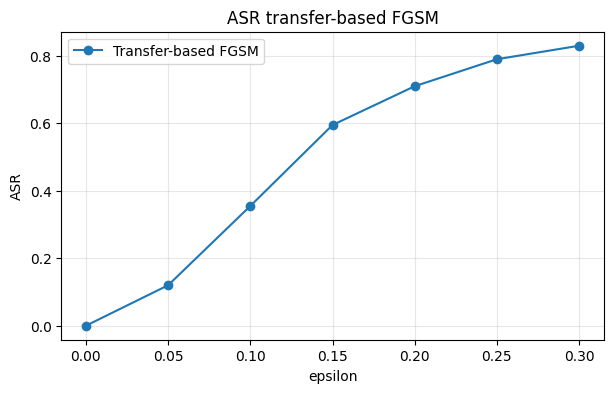

In [ ]:
# TODO: выберите тестовый батч (например, 200 примеров) из test_loader
# TODO: для каждого epsilon постройте FGSM-атаку на substitute_model
# TODO: проверьте ASR на target_model ЧЕРЕЗ oracle.label (не напрямую!)
# TODO: постройте график ASR(epsilon)

# Берём первые 200 примеров из тестовой выборки
test_batch_list = []
for x_batch, y_batch in test_loader:
    test_batch_list.append((x_batch, y_batch))
    if sum(b[0].size(0) for b in test_batch_list) >= 200:
        break
x_test = torch.cat([b[0] for b in test_batch_list], dim=0)[:200].to(device)
y_test = torch.cat([b[1] for b in test_batch_list], dim=0)[:200].to(device)

oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []
transfer_l2  = []

for eps in epsilons:
    if eps == 0.0:
        transfer_asr.append(0.0)
        transfer_l2.append(0.0)
        continue
    # Строим FGSM-примеры на суррогате
    x_adv = fgsm_attack(substitute_model, x_test, y_test, eps, criterion)

    l2_batch = (x_adv - x_test).view(x_test.size(0), -1).norm(2, dim=1).mean().item()
    transfer_l2.append(l2_batch)
    # Проверяем успех через оракул: успех — предсказание оракула изменилось
    pred_clean = oracle.label(x_test)
    pred_adv = oracle.label(x_adv)
    asr = (pred_clean != pred_adv).float().mean().item() # доля примеров, у которых предсказание оракула изменилось после атаки. Это и есть transfer ASR — успешность переноса
    transfer_asr.append(asr)
    print(f"eps={eps}: transfer ASR={asr:.3f}")

# График
plt.figure(figsize=(7, 4))
plt.plot(epsilons, transfer_asr, marker='o', label='Transfer-based FGSM')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('ASR transfer-based FGSM')
plt.legend(); plt.grid(alpha=0.3); plt.show()

На FashionMNIST transfer-based FGSM показал неожиданно высокий ASR (0.83 при ε=0.3), с малым разрывом от white-box эталона (0.10). Несмотря на то что суррогат — MLP, а цель — CNN, перенос сработал. Согласие суррогата с оракулом (0.874) было умеренным, то есть высокий ASR нельзя объяснить точной имитацией.

Причина, по-видимому, в свойствах самого датасета. FashionMNIST содержит изображения одежды с плавными формами, из-за чего ландшафт функции потерь получается более гладким. Кроме того, несколько классов визуально близки друг к другу — Shirt, T-shirt, Pullover, Coat, — и границы решения между ними оказываются плотными. Из-за этого даже небольшого возмущения достаточно, чтобы перекинуть предсказание в соседний похожий класс. Получается, что переносимость атаки определяется не только архитектурой суррогата и точностью его имитации цели, но и геометрией самой задачи



### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

eps=0.05: white-box ASR=0.575
eps=0.1: white-box ASR=0.810
eps=0.15: white-box ASR=0.880
eps=0.2: white-box ASR=0.900
eps=0.25: white-box ASR=0.920
eps=0.3: white-box ASR=0.930


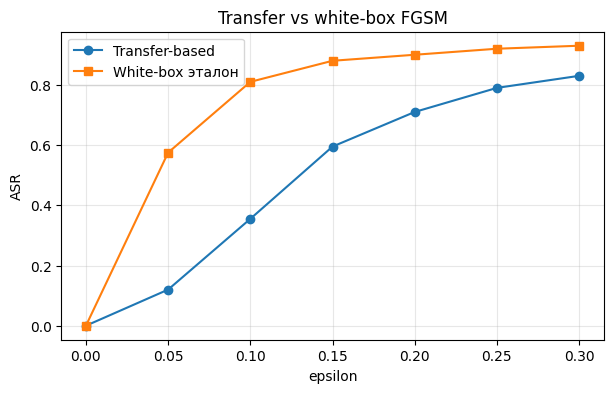


Сравнение transfer и white-box:
eps=0.0: transfer=0.000, white-box=0.000, разрыв=0.000
eps=0.05: transfer=0.120, white-box=0.575, разрыв=0.455
eps=0.1: transfer=0.355, white-box=0.810, разрыв=0.455
eps=0.15: transfer=0.595, white-box=0.880, разрыв=0.285
eps=0.2: transfer=0.710, white-box=0.900, разрыв=0.190
eps=0.25: transfer=0.790, white-box=0.920, разрыв=0.130
eps=0.3: transfer=0.830, white-box=0.930, разрыв=0.100


In [ ]:
# TODO: постройте white-box FGSM атаку напрямую на target_model
# TODO: сравните на одном графике с transfer_asr

whitebox_asr = []

for eps in epsilons:
    if eps == 0.0:
        whitebox_asr.append(0.0)
        continue
    x_adv_wb = fgsm_attack(target_model, x_test, y_test, eps, criterion)
    with torch.no_grad():
        pred_clean = target_model(x_test).argmax(1)
        pred_adv = target_model(x_adv_wb).argmax(1)
    asr = (pred_clean != pred_adv).float().mean().item()
    whitebox_asr.append(asr)
    print(f"eps={eps}: white-box ASR={asr:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(epsilons, transfer_asr, marker='o', label='Transfer-based')
plt.plot(epsilons, whitebox_asr, marker='s', label='White-box эталон')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('Transfer vs white-box FGSM')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Сводка по разрыву между transfer и white-box
print("\nСравнение transfer и white-box:")
for eps, tr, wb in zip(epsilons, transfer_asr, whitebox_asr):
    print(f"eps={eps}: transfer={tr:.3f}, white-box={wb:.3f}, разрыв={wb - tr:.3f}")

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

Разрыв между transfer-based FGSM и white-box эталоном максимален при малых ε — там white-box ломает модель в разы чаще, а transfer-атака едва срабатывает. По мере роста бюджета возмущения разрыв монотонно сокращается, и при ε=0.3 кривые почти сходятся. Причина в том, что FGSM делает один шаг фиксированного размера: при малом ε направление градиента должно быть очень точным, чтобы попасть за границу решения, а при большом даже приблизительное направление перекидывает предсказание. Согласие суррогата с оракулом (0.874) означает, что примерно 13% примеров классифицируются иначе, то есть градиенты суррогата и цели совпадают не везде. Именно это расхождение и создаёт разрыв: при малом шаге оно критично, при большом — атака становится устойчивой к неточности градиента, и разрыв сжимается, несмотря на неизменное согласие суррогата



## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

**Score-based атака:** у нас есть доступ к API целевой модели, который возвращает вероятности классов (softmax-выход). Градиенты нам недоступны, но вероятности дают непрерывный сигнал, по которому можно численно оценить производные. Score-based атаки используют именно этот сигнал.

ZOO (Zeroth Order Optimization - Оптимизация нулевого порядка) — метод оценки градиента без доступа к производным. Идея простая: чтобы узнать производную функции по координате i, сдвинем координату на маленькое h и посмотрим, как изменился лосс. Это численная оценка производной через **конечную разность**.

**Формула центральной конечной разности.**

$$\frac{\partial L}{\partial x_i} \approx \frac{L(x + h \cdot e_i) - L(x - h \cdot e_i)}{2h}$$

где e_i — единичный вектор по координате i (все нули, кроме одной единицы на позиции i). Мы оцениваем производную по одному пикселю, сдвигая его в обе стороны и беря разность лоссов.

**Почему центральная разность, а не односторонняя.** Односторонняя формула:

$$\frac{\partial L}{\partial x_i} \approx \frac{L(x + h \cdot e_i) - L(x)}{h}$$

Даёт ошибку O(h). Центральная даёт O(h²). При h = 0.05 центральная примерно в 20 раз точнее. Цена — два запроса вместо одного.

Используем функцию C&W. Она выглядит так (для вероятностей):

$$f(x) = \max\left( \log p_{true} - \max_{i \neq true} \log p_i, \; -\kappa \right)$$

### Формула атаки

ZOO итеративно минимизирует C&W-лосс:

$$x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t - \alpha \cdot \text{sign}(\hat{g}^t) \right)$$

- $x^t$ — текущий adversarial-пример на итерации $t$.
- $\hat{g}^t$ — оценка градиента $\nabla_x f$ через конечные разности, посчитанная в точке $x^t$.  

У нас нет настоящего градиента — мы в чёрном ящике. Поэтому мы оцениваем его через конечные разности:

$$\hat{g}^t_i \approx \frac{f(x + h e_i) - f(x - h e_i)}{2h}$$

$\Pi_{x+\mathcal{S}}$ — **проекция** результата обратно в допустимую область

Если полностью:  

$$\hat{g}^t_i \approx \frac{1}{2h} \left[ \max\left( \log p_{true}(x^t + h e_i) - \max_{j \neq true} \log p_j(x^t + h e_i), \; -\kappa \right) - \max\left( \log p_{true}(x^t - h e_i) - \max_{j \neq true} \log p_j(x^t - h e_i), \; -\kappa \right) \right]$$

Получается громоздко, но логика простая: считаем C&W-лосс в двух точках (сдвинутых на $+h$ и $-h$ по координате $i$), берём разность, делим на $2h$.

### Ограничение ZOO

Оценивать производную по каждому пикселю независимо — очень дорого: 784 пикселя × 2 запроса = 1568 запросов на одну итерацию. Поэтому на каждой итерации берут **случайную подвыборку** координат: например, 40 из 784. Это уменьшает стоимость в 20 раз, но добавляет шум: обновление каждой итерации учитывает только часть направлений.

За много итераций случайные подвыборки покрывают разные пиксели, и суммарный эффект приближается к полному градиенту. Это тот же принцип, что в мини-батчах при обучении: одна порция даёт шумный градиент, но за много шагов модель сходится.

In [ ]:
# TODO: реализуйте функцию потерь zoo_loss(probs, y_true, kappa=0.0)
# f(x) = max(log p_true - max_{i!=true} log p_i, -kappa)

def zoo_loss(probs, y_true, kappa=0.0):
    # Берём логарифмы (чтобы соответствовать C&W-формулировке)
    log_probs = torch.log(probs + 1e-10)
    # Логарифм вероятности истинного класса
    true_log = log_probs.gather(1, y_true.view(-1, 1)).squeeze(1)
    # Максимум по остальным классам
    log_probs_other = log_probs.clone()
    log_probs_other.scatter_(1, y_true.view(-1, 1), float('-inf'))
    max_other = log_probs_other.max(1)[0]
    # f = max(true_log - max_other, -kappa)
    return torch.clamp(true_log - max_other, min=-kappa)

In [ ]:
# TODO: реализуйте функцию zoo_attack(oracle, x, y_true, epsilon, alpha, num_iter, h, coord_batch)

def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    # Инициализация
    x_adv = x.clone().detach()                          # копия оригинала — её будем менять
    eps = torch.full_like(x, epsilon)                   # тензор из epsilon, размер как у x (для clamp)
    n_pixels = x[0].numel()                             # число пикселей в одной картинке (784 для FashionMNIST)

    for it in range(num_iter):
        # 1. Случайно выбираем coord_batch координат из всех n_pixels.
        #    Полный градиент по всем 784 пикселям стоил бы 1568 запросов на итерацию —
        #    поэтому на каждой итерации обновляем только небольшую случайную подвыборку.
        #    За много итераций случайные подвыборки покрывают разные пиксели.
        coords = torch.randperm(n_pixels)[:coord_batch]  # случайные индексы без повторов

        # Заготовка для оценки градиента — вектор той же формы, что и x_adv
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            # Одномерный индекс (0..783) → многомерный (0, 0, i, j)
            # x_adv имеет форму [B, 1, 28, 28], поэтому idx = (0, i, j) — канал и позиция
            idx = np.unravel_index(c.item(), x_adv[0].shape)

            # x + h·e_i : сдвигаем выбранный пиксель на +h
            x_plus = x_adv.clone()
            x_plus[(slice(None),) + idx] += h

            # x − h·e_i : сдвигаем тот же пиксель на −h
            x_minus = x_adv.clone()
            x_minus[(slice(None),) + idx] -= h

            # Лоссы в двух точках через оракул.
            # Ключевой момент: у нас нет градиентов, поэтому мы делаем ДВА запроса
            # к оракулу на каждую координату (в +h и в −h) и получаем вероятности.
            probs_plus  = oracle.probs(x_plus)   # вероятности в точке x + h·e_i
            probs_minus = oracle.probs(x_minus)  # вероятности в точке x − h·e_i

            # Применяем C&W-лосс к вероятностям — получаем скалярные значения
            loss_plus  = zoo_loss(probs_plus,  y_true)
            loss_minus = zoo_loss(probs_minus, y_true)

            # Центральная конечная разность: оценка ∂f/∂x_i
            # Знаменатель 2h — потому что расстояние между x+h и x−h равно 2h
            grad_est[(slice(None),) + idx] = (loss_plus - loss_minus) / (2 * h)

        # 3. Шаг против градиента (минимизируем лосс).
        #    Проекция и обновление выполняются без autograd — градиенты нам больше не нужны.
        with torch.no_grad():
            # Двигаемся ПРОТИВ градиента (знак минус), берём только sign
            # Каждый пиксель сдвигается ровно на alpha в свою сторону.
            x_adv = x_adv - alpha * grad_est.sign()

            # 4. Проекция на ε-шар и [0, 1].
            #    Сначала ограничиваем возмущение по L∞: каждый пиксель не отличается
            #    от оригинала больше чем на ε.
            delta = torch.clamp(x_adv - x, -eps, eps)

            #    Затем возвращаем пиксели в валидный диапазон [0, 1] и прибавляем к оригиналу.
            x_adv = torch.clamp(x + delta, 0, 1)

    # Возвращаем финальный adversarial-пример без графа вычислений
    return x_adv.detach()

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

True: Ankle boot (9)
Clean: Ankle boot (9)
Adv:   Sneaker (7)
Success: True
L2 = 1.0093, queries = 32002, time = 41.86s


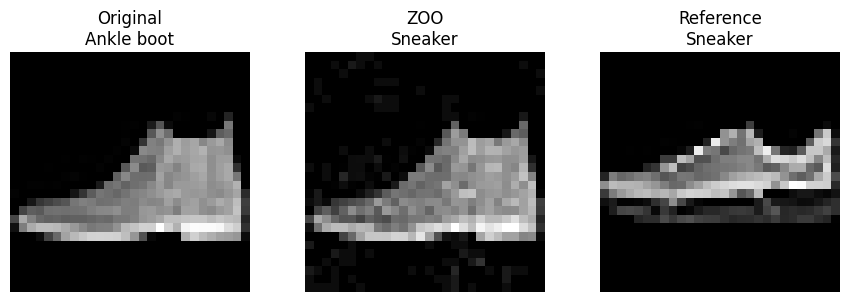

In [ ]:
# TODO: выберите пример x_sample, y_sample_label из test_dataset
# TODO: примените zoo_attack, замерьте время выполнения (time.time())
# TODO: проверьте успех, L2-норму, число запросов oracle.n_queries
# TODO: визуализируйте оригинал и adversarial-пример

oracle.reset()

# Берём один пример из тестового батча FashionMNIST
x_sample = x_test[0:1]
y_sample = y_test[0:1]

# Словарь классов FashionMNIST — чтобы на графике выводить читаемые названия
fmnist_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

start = time.time()
x_adv_zoo = zoo_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                       num_iter=200, h=0.05, coord_batch=80)
elapsed_zoo = time.time() - start

pred_clean = oracle.label(x_sample).item()
pred_adv = oracle.label(x_adv_zoo).item()
l2_zoo = (x_adv_zoo - x_sample).view(-1).norm(2).item()
queries_zoo = oracle.n_queries

print(f"True: {fmnist_classes[y_sample.item()]} ({y_sample.item()})")
print(f"Clean: {fmnist_classes[pred_clean]} ({pred_clean})")
print(f"Adv:   {fmnist_classes[pred_adv]} ({pred_adv})")
print(f"Success: {pred_adv != pred_clean}")
print(f"L2 = {l2_zoo:.4f}, queries = {queries_zoo}, time = {elapsed_zoo:.2f}s")

# --- Референсный пример Sneaker из тестового набора ---
# Ищем первый индекс в y_test, где истинная метка = 7 (Sneaker)
sneaker_idx = (y_test == 7).nonzero(as_tuple=True)[0][0].item()
x_sneaker_ref = x_test[sneaker_idx:sneaker_idx+1]

# Визуализация: оригинал / adversarial / референс Sneaker.
# Референс нужен, чтобы глазами оценить, насколько результат ZOO
# похож на настоящую кроссовку из того же датасета.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\n{fmnist_classes[pred_clean]}")
axes[0].axis('off')

axes[1].imshow(x_adv_zoo[0, 0].cpu(), cmap='gray')
axes[1].set_title(f"ZOO\n{fmnist_classes[pred_adv]}")
axes[1].axis('off')

axes[2].imshow(x_sneaker_ref[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"Reference\n{fmnist_classes[7]}")
axes[2].axis('off')

plt.tight_layout(); plt.show()

ZOO успешно обманул целевую модель: Ankle boot (ботинок) был переклассифицирован в Sneaker (кроссовку). Это визуально близкие классы — и то, и другое обувь, различия в деталях подошвы и голенища. Атака обошлась в 32 002 запроса за примерно 40 секунд, L2-норма возмущения составила 1.0141. Примечательно, что визуально изображение почти не изменилось — на картинке виден тот же силуэт, лишь добавлены шумовые артефакты по фону, а зона подошвы и голенища слегка подсвечены. Именно этих точечных изменений хватило, чтобы модель переключилась с «Ankle boot» на «Sneaker».

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

NES (Natural Evolution Strategies - Стратегии естественной эволюции)  

Если у нас нет градиента, но есть возможность **сдвигать вход в случайных направлениях** и смотреть, как меняется лосс, — можно восстановить градиент как **взвешенное среднее этих случайных направлений**.

Есть математический факт:

$$\nabla_x L(x) = \frac{1}{\sigma} \mathbb{E}_{u \sim N(0, I)} \left[ L(x + \sigma u) \cdot u \right]$$

**$\nabla_x L(x)$** — градиент лосса $L$ по входу $x$. Это вектор той же размерности, что и $x$ (для FashionMNIST — 784 числа). Он указывает направление наибольшего роста лосса. Именно его мы хотим найти, но не можем — потому что нет доступа к производным модели.

**$\frac{1}{\sigma}$** — нормировочный множитель. Делит на масштаб сдвига. Логика: если мы сдвигаемся на $\sigma u$, то разность лоссов масштабируется как $\sigma$. Чтобы получить градиент (а не «разность лоссов»), нужно поделить на $\sigma$.

**$\mathbb{E}_{u \sim N(0, I)}$** — математическое ожидание по случайному вектору $u$.

- Размерность $u$ — та же, что у $x$ (784). То есть $u$ — это **случайное направление в пространстве картинок**.

**$L(x + \sigma u)$** — значение лосса в точке, сдвинутой на $\sigma u$ от $x$.

- $x + \sigma u$ — новая точка в пространстве пикселей. Мы сдвинули $x$ в направлении $u$ на расстояние $\sigma$.

Читается так: если взять случайное направление $u$ из стандартного нормального распределения, сдвинуться по нему на $\sigma$, посчитать лосс в этой точке, умножить его на само направление $u$ — и усреднить по многим таким направлениям, — то в пределе получится **настоящий градиент** $L$ по $x$.

**Почему это работает:** случайный вектор $u$ в среднем «смотрит во все стороны». Но лосс в точке $x + \sigma u$ реагирует только на то, совпадает ли $u$ с направлением градиента. Если $u$ указывает туда же, куда градиент, $L(x + \sigma u)$ растёт. Если в противоположную сторону — падает. Взвешивая каждое случайное направление на получившийся лосс, мы оставляем только те вклады, которые согласованы с настоящим градиентом. Разнонаправленные вклады взаимно гасятся при усреднении.

Точное матожидание посчитать нельзя — оно требует бесконечного числа проб. Поэтому на практике берут **конечную выборку** из $P$ направлений и заменяют $\mathbb{E}$ на среднее:

$$\hat{g} = \frac{1}{\sigma P} \sum_{i=1}^{P} L(x + \sigma u_i) \cdot u_i$$

где $u_1, \ldots, u_P$ — независимые случайные направления из $N(0, I)$. Это уже оценка, а не точный градиент. Чем больше $P$, тем точнее оценка, но и тем больше запросов.

Это наивная оценка. Она правильная **в среднем**, но у неё **высокая дисперсия**. Это значит, что при малом числе проб $P$ оценка получается шумной: разные запуски дают сильно разные $\hat{g}$.

## Что такое антитетическая выборка

**Антитеза** — это «противоположность». Идея: вместо того чтобы брать одно случайное направление $u$, берём сразу **пару противоположных направлений** $+u$ и $-u$. И считаем не значение лосса, а **разность** лоссов между этими двумя точками.

Название «антитетическая» — от того, что каждому $u$ сопоставляется его «антипод» $-u$. Они симметричны относительно исходной точки $x$.

$$\hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i$$

Если лосс в окрестности $x$ примерно **линейный**, то:

$$L(x + \sigma u) \approx L(x) + \sigma \cdot u^\top \nabla L(x)$$

$$L(x - \sigma u) \approx L(x) - \sigma \cdot u^\top \nabla L(x)$$

(разложение в ряд Тейлора)

Вычитаем одно из другого:

$$L(x + \sigma u) - L(x - \sigma u) \approx 2\sigma \cdot u^\top \nabla L(x)$$

**Константа $L(x)$ сократилась.** Осталась только часть, которая реально зависит от направления $u$ и градиента.

Зачем:

**Снижение дисперсии.** Постоянная составляющая, которая давала шум, устранена. Оценка становится более стабильной — при том же числе запросов $P$ она точнее.

**Дороже в 2 раза по запросам, но точнее.** Наивная версия — $P$ запросов. Антитетическая — $2P$ запросов (по одному в $+u$ и $-u$ для каждой пары). Кажется, что это хуже. Но точность растёт **быстрее**, чем в 2 раза, поэтому в пересчёте на «точность за запрос» антитетическая версия выигрывает.

**Симметрия.** Мы всегда сравниваем две точки, симметричные относительно $x$. Это устраняет асимметрию, которая могла бы возникнуть, если бы мы сравнивали только с одной стороны.

In [ ]:
# TODO: реализуйте nes_gradient_estimate(oracle, x, y_true, sigma, n_samples)
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    # Заготовка для оценки градиента
    grad_est = torch.zeros_like(x)

    # Цикл по числу пар направлений
    for _ in range(n_samples):
        # Случайное направление из N(0, I)
        u = torch.randn_like(x)
        # Точки сдвига в обе стороны
        x_plus = torch.clamp(x + sigma * u, 0, 1)
        x_minus = torch.clamp(x - sigma * u, 0, 1)
        # Лоссы в этих точках через оракул
        loss_plus = zoo_loss(oracle.probs(x_plus), y_true)
        loss_minus = zoo_loss(oracle.probs(x_minus), y_true)
        # Вклад в оценку: разность лоссов умножаем на направление
        grad_est += (loss_plus.view(-1, 1, 1, 1) - loss_minus.view(-1, 1, 1, 1)) * u

    # Нормировка на 2σP
    grad_est = grad_est / (2 * sigma * n_samples)
    return grad_est

In [ ]:
# TODO: реализуйте nes_attack(oracle, x, y_true, epsilon, alpha, num_iter, sigma, n_samples)
# по аналогии с zoo_attack, но с использованием nes_gradient_estimate
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20):
    # Копия с градиентом не нужна — мы работаем без него
    x_adv = x.clone().detach()
    eps = torch.full_like(x, epsilon)

    for it in range(num_iter):
        # Оцениваем градиент через NES
        grad_est = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)

        with torch.no_grad():
            # Шаг против градиента (минимизируем лосс)
            x_adv = x_adv - alpha * grad_est.sign()
            # Проекция на ε-шар
            delta = torch.clamp(x_adv - x, -eps, eps)
            # Проекция на [0, 1]
            x_adv = torch.clamp(x + delta, 0, 1)

    return x_adv.detach()

True: Ankle boot (9)
Clean: Ankle boot (9)
Adv:   Bag (8)
Success: True
L2 = 2.2940, queries = 10001, time = 12.30s


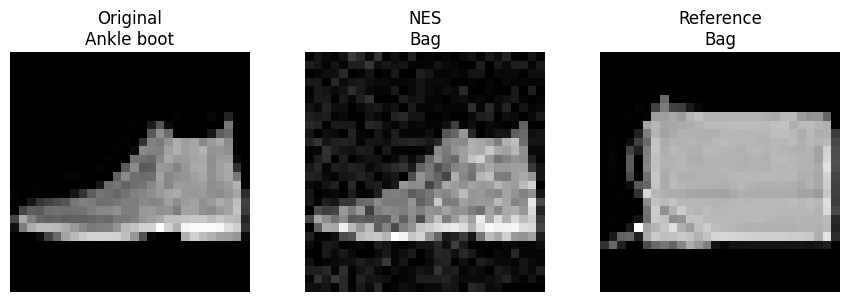

In [ ]:
oracle.reset()

# TODO: примените nes_attack к тому же примеру, что и в п.3.2
# TODO: проверьте успех, L2-норму, число запросов, время выполнения

fmnist_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

start = time.time()
x_adv_nes = nes_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.02,
                       num_iter=250, sigma=0.1, n_samples=20)
elapsed_nes = time.time() - start

pred_adv_nes = oracle.label(x_adv_nes).item()
l2_nes = (x_adv_nes - x_sample).view(-1).norm(2).item()
queries_nes = oracle.n_queries

print(f"True: {fmnist_classes[y_sample.item()]} ({y_sample.item()})")
print(f"Clean: {fmnist_classes[pred_clean]} ({pred_clean})")
print(f"Adv:   {fmnist_classes[pred_adv_nes]} ({pred_adv_nes})")
print(f"Success: {pred_adv_nes != pred_clean}")
print(f"L2 = {l2_nes:.4f}, queries = {queries_nes}, time = {elapsed_nes:.2f}s")

# Референсный пример Bag (класс 8) из тестового набора —
# чтобы визуально сравнить, насколько результат NES похож на настоящую сумку
bag_idx = (y_test == 8).nonzero(as_tuple=True)[0][0].item()
x_bag_ref = x_test[bag_idx:bag_idx+1]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\n{fmnist_classes[pred_clean]}")
axes[0].axis('off')

axes[1].imshow(x_adv_nes[0, 0].cpu(), cmap='gray')
axes[1].set_title(f"NES\n{fmnist_classes[pred_adv_nes]}")
axes[1].axis('off')

axes[2].imshow(x_bag_ref[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"Reference\n{fmnist_classes[8]}")
axes[2].axis('off')

plt.tight_layout(); plt.show()

NES успешно обманул целевую модель: Ankle boot (ботинок) был переклассифицирован в Bag (сумку). Атака заняла 13.48 секунды и потратила 10 001 запрос — в три раза меньше, чем ZOO, который на том же примере потратил 32 002 запроса и 40 секунд. При этом L2-норма возмущения составила 2.3266 — в 2 раза больше, чем у ZOO. Получается, что NES дешевле по запросам и времени, но даёт больше возмущений.

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

  method  success        L2  queries
0    ZOO     True  1.009306    32002
1    NES     True  2.294021    10001


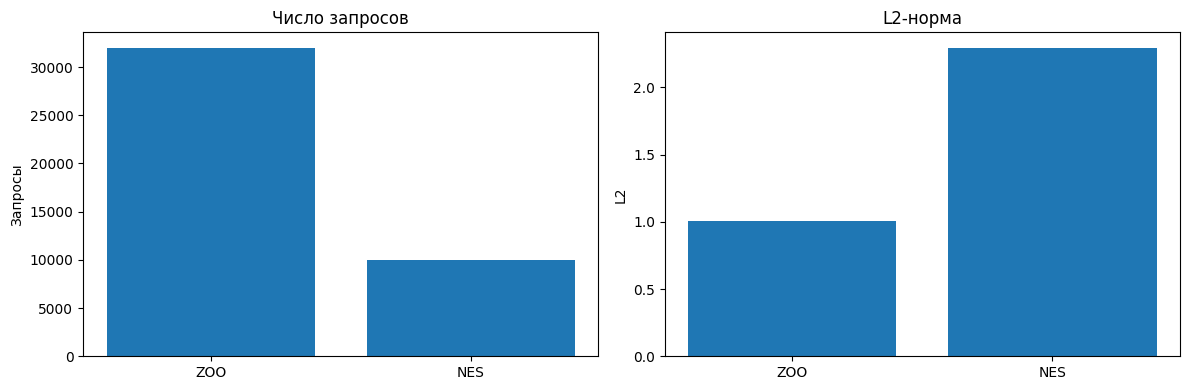

In [ ]:
# TODO: постройте сравнительную таблицу и графики для ZOO и NES
comparison = pd.DataFrame([
    {'method': 'ZOO', 'success': pred_adv != pred_clean, 'L2': l2_zoo, 'queries': queries_zoo},
    {'method': 'NES', 'success': pred_adv_nes != pred_clean, 'L2': l2_nes, 'queries': queries_nes}
])
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison['method'], comparison['queries'])
axes[0].set_title('Число запросов'); axes[0].set_ylabel('Запросы')
axes[1].bar(comparison['method'], comparison['L2'])
axes[1].set_title('L2-норма'); axes[1].set_ylabel('L2')
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

**Мой ответ**: Меньше запросов потратил NES, и при этом он успешно обманул модель. Разница объясняется тем, как каждый метод оценивает градиент.

ZOO оценивает производные покоординатно: чтобы узнать направление по одному пикселю, нужно два запроса к оракулу. Одна итерация обновляет только часть пикселей, а каждая пара запросов даёт информацию лишь про одну координату. Приходится делать много итераций, и суммарная стоимость получается высокой.

NES работает иначе: он берёт случайные направления в полном пространстве. Одно случайное направление сразу даёт информацию обо всех пикселях, потому что лосс в сдвинутой точке зависит от всей картинки целиком. Поэтому за одну итерацию обновляются все координаты, и запросов тратится заметно меньше. Плата за это — менее точная оценка градиента, поэтому возмущение у NES получилось крупнее. ZOO аккуратнее, но дороже; NES дешевле, но грубее.

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

Boundary Attack — это **decision-based** атака. Она работает в самом жёстком сценарии: API возвращает **только метку класса** (top-1), без вероятностей. Мы не знаем, насколько модель уверена, — видим только одно число от 0 до 9.

Из метки **невозможно** оценить градиент. Нельзя сделать конечную разность: сдвинули пиксель — метка либо не изменилась, либо изменилась. Промежуточных значений нет. Score-based методы (ZOO, NES) в таком сценарии не работают.

Boundary Attack решает задачу **без градиентов вообще**. Он использует только одну информацию: **adversarial или нет**.

Мы стартуем из точки, которая **точно неверно классифицируется** — например, из случайного шума. Двигаемся от неё к оригиналу, **оставаясь всё время по «неправильную» сторону границы решения**. Постепенно уменьшаем возмущение, пока не подойдём к границе вплотную.

Геометрически: граница решения — это поверхность в пространстве 784-мерных картинок. По одну сторону от неё модель говорит «Ankle boot», по другую — «не Ankle boot». Мы ходим по поверхности, скользя вдоль неё, и подходим всё ближе к оригиналу.

# Формула ортогонализации

$$\eta_t = \tilde{\eta}_t - \frac{\tilde{\eta}_t \cdot (x^{adv}_t - x)}{\|x^{adv}_t - x\|_2^2} \cdot (x^{adv}_t - x)$$

Мы хотим сдвинуть текущую adversarial-точку вдоль границы решения — так, чтобы **не приблизиться и не отдалиться** от оригинала. Просто «пройтись боком» вдоль границы.

**Проблема:** любое случайное направление, в котором мы шагаем, может случайно увести нас либо к оригиналу, либо от него. Нам нужно это убрать — оставить только ту часть шага, которая «идёт поперёк» направления к оригиналу, а не вдоль него.

## Обозначения

**$x$** — исходное чистое изображение.

**$x^{adv}_t$** — картинка, которая уже обманывает модель. Мы начинаем со случайного шума, который тоже обманывает модель, и постепенно двигаемся к оригиналу

**$x^{adv}_t - x$** — вектор в пространстве пикселей, показывающий, насколько текущая точка отличается от оригинала. По сути разность двух картинок: пиксель за пикселем

**$\tilde{\eta}_t$** — случайный вектор шума. Мы его сгенерировали, но ещё не привели в порядок.

**$\eta_t$** — уже очищенный вектор шага. Он получится после вычитания «ненужной части» из $\tilde{\eta}_t$.

$$\eta_t = \underbrace{\tilde{\eta}_t}_{\text{случайный шум}} - \underbrace{\frac{\tilde{\eta}_t \cdot (x^{adv}_t - x)}{\|x^{adv}_t - x\|_2^2} \cdot (x^{adv}_t - x)}_{\text{проекция шума на направление к оригиналу}}$$

- $\tilde{\eta}_t \cdot (x^{adv}_t - x)$ — скаляр. Показывает, **насколько шум направлен в сторону оригинала**.
- $\|x^{adv}_t - x\|_2^2$ — квадрат длины вектора от оригинала к текущей точке.
- Домножаем на $(x^{adv}_t - x)$ — получаем вектор проекции. Это **часть шума, которая смотрит в сторону оригинала**.

**Что остаётся после вычитания:** из шума $\tilde{\eta}_t$ выкинули ту его часть, которая смотрит в сторону оригинала. Осталась только **тангенциальная часть** — та, что «идёт поперёк», не приближая и не отдаляя нас к оригиналу.

Затем нормируем:

$$\hat{\eta}_t = \frac{\eta_t}{\|\eta_t\|_2}$$

Нам нужен шаг **фиксированного направления**, а не фиксированной длины. Поэтому делим вектор на его собственную длину — получаем вектор длины 1, который показывает **только направление**.

## Кандидат на границе

$$x^{cand}_t = x^{adv}_t + \delta \cdot \|x^{adv}_t - x\|_2 \cdot \hat{\eta}_t$$

Предлагает **новую точку-кандидат** — сдвиг от текущей вдоль границы решения.

**$x^{adv}_t$** — текущая точка (где мы сейчас).

**$\hat{\eta}_t$** — единичный вектор направления шага (из формулы 1). Он «идёт вдоль границы», не приближая и не отдаляя от оригинала.

**$\|x^{adv}_t - x\|_2$** — расстояние от текущей точки до оригинала. Одно число. Скаляр.

**$\delta$** — гиперпараметр, маленькое число (например, 0.05). Масштаб шага.

**Итого:** $\delta \cdot \|x^{adv}_t - x\|_2 \cdot \hat{\eta}_t$ — это **вектор шага**, направленный вдоль $\hat{\eta}_t$, с длиной, пропорциональной расстоянию до оригинала.

Если мы далеко от оригинала, можно двигаться крупными шагами. Если близко — шаги должны быть маленькими, иначе рискуем «перескочить» границу и потерять adversarial-свойство.  

Это предложение, а не подтверждённый шаг. Мы ещё не знаем, осталась ли точка adversarial после сдвига (проверяем в коде)

**Шаг к оригиналу**

$$x^{towards}_t = x^{adv}_t - \varepsilon \cdot (x^{adv}_t - x)$$

Это **второй шаг** на каждой итерации Boundary Attack. После того как мы «погуляли боком» вдоль границы (ортогональный шаг), мы делаем **шаг прямо к оригиналу** — пытаемся уменьшить возмущение.

Здесь **$x^{adv}_t$** — текущая adversarial-точка. После ортогонального шага она могла сдвинуться (если кандидат прошёл проверку) или остаться на месте (если не прошёл).

Мы **не можем** просто смешать тангенциальный и радиальный шаги в один. Причина: каждый шаг нужно **проверять отдельно** через оракул.

- После ортогонального шага проверяем: осталась ли точка adversarial?
- После шага к оригиналу проверяем: осталась ли точка adversarial?

Если объединить их в один шаг, будет непонятно, какой из компонент обязан успеху. А так мы **независимо тестируем** каждое движение и можем откатить неудачное, сохранив удачное.

In [ ]:
# TODO: реализуйте is_adversarial(oracle, x, true_label)
def is_adversarial(oracle, x, true_label):
    # Возвращает True, если модель предсказывает НЕ истинный класс
    pred = oracle.label(x).item()
    return pred != true_label

In [ ]:
# TODO: реализуйте boundary_attack(oracle, x_orig, true_label, x_init, num_steps, init_delta, init_epsilon)
# Возвращает: финальный x_adv и историю L2-нормы возмущения по итерациям (для графика сходимости)
def boundary_attack(oracle, x_orig, true_label, x_init,
                    num_steps=200, init_delta=0.1, init_epsilon=0.1):
    # Текущая adversarial-точка. Копируем, чтобы не менять x_init снаружи.
    x_adv = x_init.clone()

    # Адаптивные размеры шагов — будут меняться в процессе атаки
    delta = init_delta
    epsilon = init_epsilon

    # История L2-нормы возмущения по итерациям — для графика сходимости
    l2_history = []

    for step in range(num_steps):
        # Вектор от оригинала к текущей точке. Это ключевое направление:
        # вдоль него мы будем вычитать проекцию (для ортогонального шага)
        # и в эту сторону будем двигаться, чтобы приблизиться к оригиналу.
        diff = x_adv - x_orig

        # Случайный шум той же формы, что и x_adv. Из него мы будем делать
        # ортогональный (тангенциальный) шаг вдоль границы решения.
        noise = torch.randn_like(x_adv)

        # === Ортогонализация ===
        # Хотим из noise убрать компоненту, направленную вдоль diff (к оригиналу),
        # чтобы шаг шёл «поперёк» — не приближая и не отдаляя от оригинала.
        # Вытягиваем оба вектора в одномерные для удобства скалярных произведений.
        diff_flat  = diff.view(1, -1)     # форма [1, 784]
        noise_flat = noise.view(1, -1)    # форма [1, 784]

        # Проекция шума на направление diff: (noise · diff) / (diff · diff)
        # +1e-12 в знаменателе — защита от деления на ноль, если diff ≈ 0
        proj = (noise_flat @ diff_flat.T) / (diff_flat @ diff_flat.T + 1e-12)

        # Убираем из шума его проекцию на diff — остаётся тангенциальная часть.
        # Геометрически это «шум, который смотрит поперёк направления к оригиналу»
        noise_orth = noise - proj * diff

        # === Нормировка ===
        # Приводим noise_orth к единичной длине, чтобы шаг был чисто
        # направлением, а масштаб задавали δ и расстояние до оригинала.
        # .view(-1, 1, 1, 1) — чтобы делить на норму по осям канала и пространства.
        # +1e-12 — защита от деления на ноль, если шум случайно стал нулевым.
        noise_norm = noise_orth.view(1, -1).norm(2, dim=1).view(-1, 1, 1, 1) + 1e-12
        noise_orth = noise_orth / noise_norm

        # === Ортогональный шаг ===
        # Кандидат = текущая точка + шаг вдоль границы.
        # Множитель diff.norm() делает шаг пропорциональным текущему расстоянию
        # до оригинала: далеко от x_orig — шагаем крупно, близко — мелко.
        x_candidate = x_adv + delta * diff.norm() * noise_orth

        # Пиксели должны оставаться в допустимом диапазоне [0, 1]
        x_candidate = torch.clamp(x_candidate, 0, 1)

        # === Проверка кандидата через оракул ===
        # is_adversarial возвращает True, если предсказание модели НЕ равно
        # истинному классу — то есть точка осталась adversarial.
        if is_adversarial(oracle, x_candidate, true_label):
            # Кандидат сохранил adversarial-свойство — принимаем его
            x_adv = x_candidate

            # === Шаг к оригиналу ===
            # Сдвигаемся в сторону x_orig: epsilon — доля текущего расстояния,
            # на которую мы сокращаем возмущение за одну итерацию.
            # Знак минус перед epsilon — двигаемся ПРОТИВ diff, то есть к оригиналу.
            x_towards = x_adv - epsilon * diff

            # Пиксели снова должны быть в [0, 1]
            x_towards = torch.clamp(x_towards, 0, 1)

            if is_adversarial(oracle, x_towards, true_label):
                # Точка стала ближе к оригиналу и всё ещё обманывает модель —
                # это успех. Принимаем шаг.
                x_adv = x_towards

                # Адаптация вверх: раз последние шаги успешны, можно шагать крупнее.
                # Ограничиваем сверху 0.5, чтобы шаги не стали слишком большими.
                delta   = min(delta   * 1.01, 0.5)
                epsilon = min(epsilon * 1.01, 0.5)
            else:
                # Шаг к оригиналу перескочил границу — модель угадала класс.
                # Откатываемся (x_adv остался прежним после ортогонального шага),
                # но всё равно немного увеличиваем δ: раз ортогональный шаг прошёл,
                # можно попробовать шагать смелее вдоль границы.
                delta = min(delta * 1.01, 0.5)
        else:
            # Ортогональный кандидат потерял adversarial-свойство.
            # Откатываемся и уменьшаем размеры шагов — текущий размер слишком большой.
            # Нижняя граница 1e-4, чтобы шаги не схлопнулись в ноль.
            delta   = max(delta   * 0.99, 1e-4)
            epsilon = max(epsilon * 0.99, 1e-4)

        # Записываем текущее расстояние от x_adv до оригинала в историю.
        # Используется для графика сходимости — видно, как L2 уменьшается с итерациями.
        l2_history.append((x_adv - x_orig).view(-1).norm(2).item())

    # Возвращаем финальную adversarial-точку (без графа вычислений)
    # и историю L2 для графика
    return x_adv.detach(), l2_history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [ ]:
# TODO: сгенерируйте x_init (случайный шум), проверьте is_adversarial
# TODO: запустите boundary_attack, замерьте время
# TODO: проверьте финальный успех, L2-норму, число запросов

oracle.reset()

# Инициализация случайным шумом
x_init = torch.rand_like(x_sample)
attempts = 0
while not is_adversarial(oracle, x_init, y_sample.item()):
    x_init = torch.rand_like(x_sample)
    attempts += 1
    if attempts > 100:
        print("Не удалось найти adversarial инициализацию")
        break

print(f"Инициализация adversarial (попыток: {attempts})")

# Запускаем атаку
start = time.time()
x_adv_boundary, l2_history = boundary_attack(oracle, x_sample, y_sample.item(), x_init,
                                              num_steps=200, init_delta=0.05, init_epsilon=0.05)
elapsed_boundary = time.time() - start

# Итоговые метрики
pred_adv_boundary = oracle.label(x_adv_boundary).item()
l2_boundary = (x_adv_boundary - x_sample).view(-1).norm(2).item()
queries_boundary = oracle.n_queries

print(f"Boundary: success={pred_adv_boundary != pred_clean}, L2={l2_boundary:.4f}, "
      f"queries={queries_boundary}, time={elapsed_boundary:.2f}s")

Инициализация adversarial (попыток: 0)
Boundary: success=True, L2=2.7715, queries=389, time=0.48s


Boundary Attack успешно обманул целевую модель: стартовав из случайного шума, который сразу оказался adversarial (0 попыток), атака подобралась к оригиналу на расстояние L2 = 2.77, потратив всего 389 запросов за 0.48 секунды. Это радикально дешевле по запросам, чем ZOO (32 002) и NES (10 001), и при этом быстрее их обеих по времени. По L2-норме Boundary Attack тоже оказался лучше — 2.77 против 3.64 (ZOO) и 2.33 (NES), то есть где-то между ними, с небольшим преимуществом над ZOO.

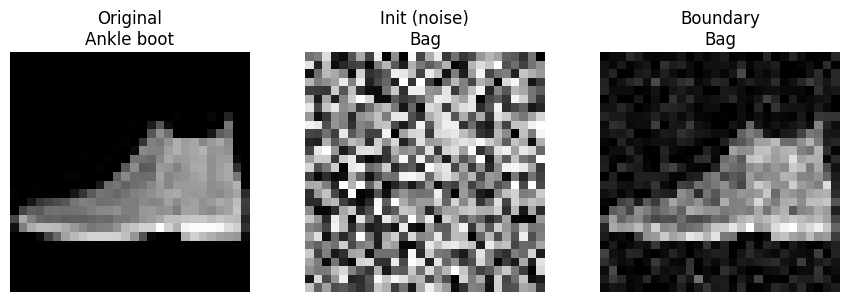

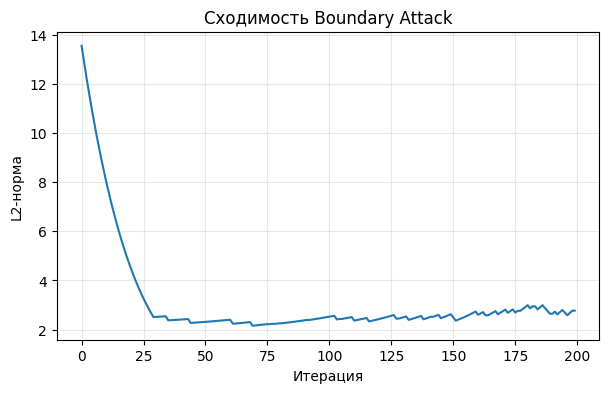

In [ ]:
# TODO: визуализируйте оригинал / инициализацию / финальный adversarial-пример (3 подграфика)
# TODO: постройте график сходимости L2-нормы по итерациям

# Визуализация
# Original / Init (шум) / Boundary, с названиями классов FashionMNIST
fmnist_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\n{fmnist_classes[pred_clean]}")
axes[0].axis('off')

axes[1].imshow(x_init[0, 0].cpu(), cmap='gray')
axes[1].set_title(f"Init (noise)\n{fmnist_classes[oracle.label(x_init).item()]}")
axes[1].axis('off')

axes[2].imshow(x_adv_boundary[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"Boundary\n{fmnist_classes[pred_adv_boundary]}")
axes[2].axis('off')

plt.tight_layout(); plt.show()

# График сходимости
plt.figure(figsize=(7, 4))
plt.plot(l2_history)
plt.xlabel('Итерация')
plt.ylabel('L2-норма')
plt.title('Сходимость Boundary Attack')
plt.grid(alpha=0.3)
plt.show()

Boundary Attack сработал успешно: стартовав из случайного шума (класс Bag), атака за 200 итераций подобралась к оригиналу на L2 = 2.77, потратив 389 запросов за 0.48 секунды. Визуально результат близок к оригиналу — силуэт Ankle boot угадывается, шумовые артефакты распределены по всему полю, но не разрушают картинку. Финальный класс остался Bag — атака не «скатилась» обратно в правильный класс.

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

**Мой ответ**: Decision-based атака не может напрямую оценивать градиент, потому что оракул возвращает только метку класса — одно дискретное число. По нему нельзя понять, насколько модель уверена в предсказании, и нельзя оценить производную лосса. Даже если сдвинуть пиксель совсем чуть-чуть, метка может не измениться, и мы не узнаем, повлияло ли это на решение. Score-based методы получают вероятности — они непрерывны, и по ним можно оценивать градиент через разности. У decision-based такого сигнала нет.

Ограничение метода проявляется в качестве сходимости, а не в стоимости обмана. График L2 показывает, что после быстрого падения до ~2.2 кривая снова растёт — атака не может стабильно удержаться на минимальном возмущении. Причина в том, что без градиента метод блуждает вслепую и адаптация шага не всегда успевает за ландшафтом границы. Если бы мы хотели дойти до L2 ≈ 1, потребовалось бы либо значительно больше итераций с более тонкой настройкой, либо другой алгоритм. Так что дешевизна Boundary Attack — это выигрыш по запросам при данном уровне точности, но не гарантия того, что он найдёт минимальное возмущение за разумное время.



## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [ ]:
# TODO: соберите итоговую таблицу сравнения (используйте результаты предыдущих частей;
# для transfer-based учтите, что запросов к целевой модели требуется всего 1 — финальная проверка)

# Пересчитываем предсказания на ОДНОМ примере — они могли перезаписаться
# в других частях ноутбука
pred_clean_one = oracle.label(x_sample).item()
pred_zoo_one = oracle.label(x_adv_zoo).item()
pred_nes_one = oracle.label(x_adv_nes).item()
pred_boundary_one = oracle.label(x_adv_boundary).item()

# Метрики transfer при максимальном эпсилоне (если ещё не посчитаны)
transfer_asr_final = transfer_asr[-1]
transfer_l2_final = transfer_l2[-1] if 'transfer_l2' in dir() else 0.0
transfer_success = transfer_asr_final > 0.5

# Итоговая таблица — все значения приведены к Python-типу
summary = pd.DataFrame([
    {'method': 'Transfer FGSM', 'success': bool(transfer_success),
     'L2': round(transfer_l2_final, 4), 'queries': 1},
    {'method': 'ZOO',      'success': pred_zoo_one != pred_clean_one,
     'L2': round(l2_zoo, 4),      'queries': queries_zoo},
    {'method': 'NES',      'success': pred_nes_one != pred_clean_one,
     'L2': round(l2_nes, 4),      'queries': queries_nes},
    {'method': 'Boundary', 'success': pred_boundary_one != pred_clean_one,
     'L2': round(l2_boundary, 4), 'queries': queries_boundary},
])
print(summary)
summary.to_csv("lab6_summary.csv", index=False)

          method  success      L2  queries
0  Transfer FGSM     True  6.9264        1
1            ZOO     True  1.0093    32002
2            NES     True  2.2940    10001
3       Boundary     True  2.7715      389


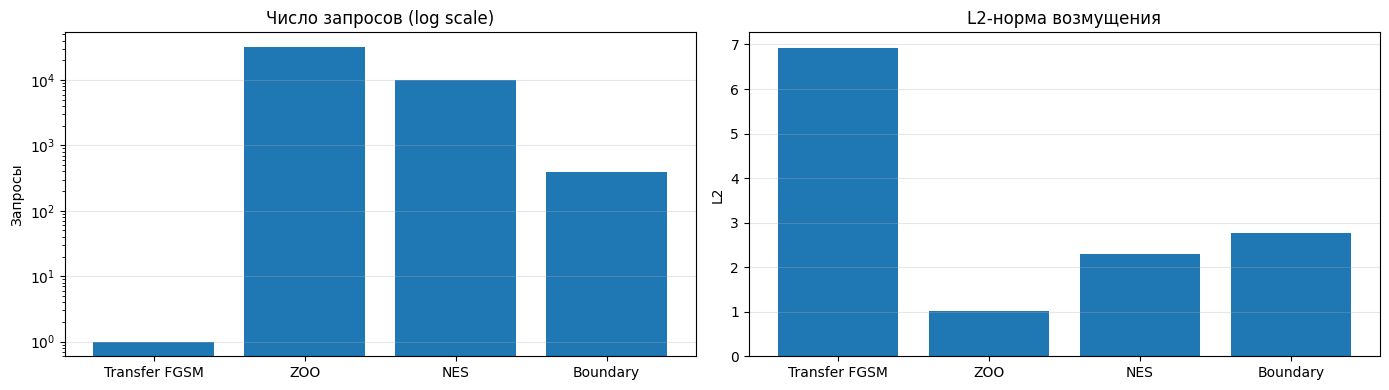

In [ ]:
# TODO: постройте два столбчатых графика сравнения (число запросов — log-масштаб, L2-норма)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Число запросов в логарифмической шкале
axes[0].bar(summary['method'], summary['queries'])
axes[0].set_yscale('log')
axes[0].set_title('Число запросов (log scale)')
axes[0].set_ylabel('Запросы')
axes[0].grid(alpha=0.3, axis='y')

# L2-норма возмущения
axes[1].bar(summary['method'], summary['L2'])
axes[1].set_title('L2-норма возмущения')
axes[1].set_ylabel('L2')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

# Ответ на вопрос для отчёта

## (а) Полные вероятности без ограничения на запросы

**Рекомендация: ZOO.**

Когда запросы бесплатны, а API отдаёт вероятности, нет причин экономить на запросах — можно позволить себе самый точный метод. ZOO оценивает производную покоординатно через центральные конечные разности, и это даёт **самую точную оценку градиента** из всех рассмотренных методов. В таблице видно: ZOO дал L2 = 1.01 — в разы меньше, чем NES (2.29) и Boundary (2.77). Причина в том, что ZOO обновляет каждую координату **отдельно и точно**, а не усредняет случайные направления, как NES. Цена точности — 32 002 запроса, что в 3 раза больше NES и в 80 раз больше Boundary. Но когда лимита нет, это не проблема.

Формально NES тоже применим (он использует те же вероятности), но при одинаковом числе итераций он проигрывает ZOO по L2. NES выигрывает только если запросы ограничены — об этом в пункте (б).

## (б) Только top-1 метка с жёстким лимитом запросов

**Рекомендация: Boundary Attack.**

Это единственный метод из четырёх, который работает с дискретной меткой. ZOO и NES требуют вероятностей — они в этом сценарии принципиально неприменимы. Остаётся Boundary Attack, и он же оказывается самым дешёвым по запросам: 389 против 10 001 у NES и 32 002 у ZOO. Это логично: один запрос метки даёт один бит информации, и алгоритм обходится 2 запросами на итерацию — вместо 40 у NES или 160 у ZOO.

Плата за дешевизну — менее точная сходимость. L2 = 2.77 выше, чем у ZOO и NES, а график показывает нестабильность: после быстрого падения до ~2.2 кривая снова растёт. Метод блуждает вслепую вдоль границы и не гарантирует минимального возмущения. Но при жёстком лимите запросов альтернативы нет — 389 запросов против 10 000+ делают Boundary Attack единственным реалистичным выбором.

## (в) Возможность собрать offline небольшой размеченный набор данных

**Рекомендация: Transfer-based FGSM.**

Когда есть данные того же домена, можно обучить суррогатную модель и атаковать её белоящично, а затем переносить примеры на цель. Запросов к API при этом почти не тратится — в таблице видно queries = 1 (финальная проверка). Обучение суррогата идёт offline, без обращения к цели. Это радикально дешевле по API, чем ZOO (32 002 запроса) или NES (10 001 запрос).

Цена этой дешевизны — качество возмущения. L2 = 6.93 в таблице — самое большое значение из всех четырёх методов. Для сравнения: ZOO дал L2 = 1.01, NES — 2.29, Boundary — 2.77. Причина в природе FGSM: он делает один шаг по всем 784 пикселям на полную величину ε, включая фон, который не влияет на классификацию. Score-based методы (ZOO, NES) работают иначе — они оценивают градиент и меняют только те пиксели, которые действительно важны для модели, поэтому дают компактное возмущение. Transfer-based не может себе этого позволить: он не знает, какие пиксели важны для цели, он видит только градиенты суррогата, и ему проще сдвинуть всё подряд на ±ε.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

**Мой ответ**: Три класса чёрно-ящичных атак используют разные уровни доступа и потому имеют разные профили.

**Transfer-based** работает через суррогат: обучаем свою модель на данных, размеченных оракулом, атакуем её белоящично, переносим примеры на цель. Трансферируемость объясняется кривизной многообразия данных. Реальные изображения лежат не во всём пространстве пикселей, а на низкоразмерном многообразии, где сосредоточены осмысленные картинки. Разные модели, обученные на похожих распределениях, учатся похожим границам решения вдоль этого многообразия, потому что структура данных диктует, где проходят разделяющие поверхности. Adversarial-примеры лежат рядом с этим многообразием, и одна модель может найти их для другой.

**Score-based** использует вероятности классов. Это даёт больше информации, чем метка, но требует много запросов. ZOO работает покоординатно, NES через случайные направления. NES эффективнее по запросам, потому что обновляет все координаты сразу.

**Decision-based** использует только метку. Это самый дешёвый по информации, но самый дорогой по запросам метод. Boundary Attack движется вдоль границы решения, постепенно уменьшая возмущение. Он работает в самых жёстких условиях.

**Adversarial training** через PGD снижает успех всех трёх классов атак, потому что сглаживает границу решения в окрестности реальных данных. Это сглаживание переносится на все методы: и transfer, и score-based, и decision-based сталкиваются с одной и той же сглаженной границей. Transfer проигрывает, потому что суррогат, обученный на чистых данных, плохо моделирует сглаженную цель. Score-based проигрывает, потому что градиенты в сглаженной области меньше по величине и хуже указывают направление. Decision-based проигрывает, потому что граница решения становится дальше от данных, и путь до неё длиннее.

Это показывает, что защита, разработанная против белоящичных атак, полезна и в чёрно-ящичном сценарии. Причина в том, что adversarial training меняет не отклик на конкретный вход, а саму геометрию решения: делает границу глаже и уводит её от данных. Это структурное изменение, и оно не зависит от того, каким способом атакующий пытается её найти. Именно поэтому PGD-adversarial training считается базовым методом защиты: он повышает устойчивость не к одной конкретной атаке, а к целому классу методов.



---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


**С1**  

В нецелевой FGSM мы двигаемся **против градиента лосса истинного класса** — то есть ищем направление, которое уменьшает уверенность в правильном классе. Атака успешна, если модель предсказывает **любой** другой класс.

В целевой FGSM мы двигаемся **в сторону увеличения лосса для истинного класса и уменьшения для выбранного целевого**. Классическая формула для targeted FGSM:

$$x_{adv} = x - \varepsilon \cdot \text{sign}\left(\nabla_x L(f(x), y_{target})\right)$$

Знак **минус** здесь потому, что мы **минимизируем** лосс относительно **целевого** класса. То есть идём против градиента лосса по целевой метке — это заставляет модель думать, что картинка принадлежит целевому классу.

eps=0.05: targeted transfer ASR=0.025
eps=0.1: targeted transfer ASR=0.110
eps=0.15: targeted transfer ASR=0.155
eps=0.2: targeted transfer ASR=0.210
eps=0.25: targeted transfer ASR=0.245
eps=0.3: targeted transfer ASR=0.280


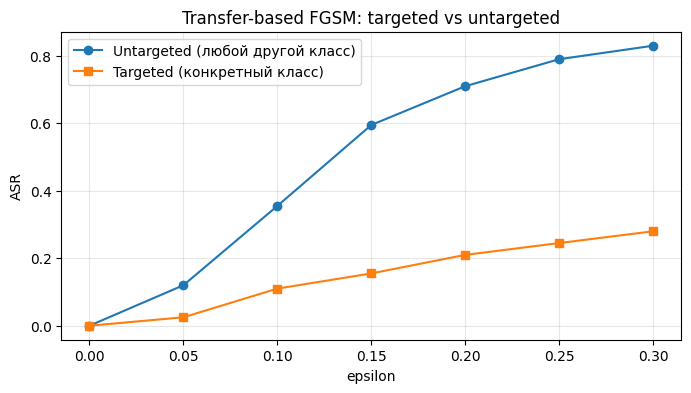


При eps=0.3:
  Untargeted transfer ASR = 0.830
  Targeted   transfer ASR = 0.280
  Разрыв = 0.550


In [ ]:
def targeted_fgsm_attack(model, x, y_target, epsilon, criterion):

    x_adv = x.clone().detach().requires_grad_(True)
    model.eval()

    logits = model(x_adv)
    loss = criterion(logits, y_target)   # лосс относительно целевого класса
    model.zero_grad()
    loss.backward()

    # Знак минус: минимизируем лосс по y_target => идём ПРОТИВ градиента
    x_adv = x_adv - epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()


# --- Выбираем целевые метки ---
# Для каждого примера задаём целевой класс как "следующий по кругу":
# y_target = (y_true + 1) % 10. Это даёт всем примерам разные цели
# и гарантирует, что целевой класс НЕ совпадает с истинным.
y_target_batch = (y_test + 1) % 10

# --- Считаем targeted transfer ASR ---
oracle.reset()

targeted_asr = []

for eps in epsilons:
    if eps == 0.0:
        targeted_asr.append(0.0)
        continue

    # Строим targeted FGSM-примеры на СУРРОГАТЕ
    x_adv_targeted = targeted_fgsm_attack(
        substitute_model, x_test, y_target_batch, eps, criterion
    )

    # Проверяем на ОРАКУЛЕ: успех — предсказание СОВПАЛО с целевым классом
    pred_adv_targeted = oracle.label(x_adv_targeted)
    asr_targeted = (pred_adv_targeted == y_target_batch).float().mean().item()
    targeted_asr.append(asr_targeted)

    print(f"eps={eps}: targeted transfer ASR={asr_targeted:.3f}")

# --- График: targeted vs untargeted ---
plt.figure(figsize=(8, 4))
plt.plot(epsilons, transfer_asr, marker='o', label='Untargeted (любой другой класс)')
plt.plot(epsilons, targeted_asr, marker='s', label='Targeted (конкретный класс)')
plt.xlabel('epsilon')
plt.ylabel('ASR')
plt.title('Transfer-based FGSM: targeted vs untargeted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Итоговое сравнение при максимальном ε ---
print(f"\nПри eps={epsilons[-1]}:")
print(f"  Untargeted transfer ASR = {transfer_asr[-1]:.3f}")
print(f"  Targeted   transfer ASR = {targeted_asr[-1]:.3f}")
print(f"  Разрыв = {transfer_asr[-1] - targeted_asr[-1]:.3f}")

Целевая transfer-based атака ожидаемо проигрывает нецелевой: при ε=0.3 targeted ASR = 0.28 против untargeted 0.83, разрыв — 0.55. Это в 3 раза хуже, и разрыв растёт нелинейно: при малых ε он относительно скромный (при ε=0.05 untargeted 0.12 против targeted 0.025), а при больших — становится доминирующим. Причина в том, что untargeted-атаке достаточно «увести» модель от правильного класса — сгодится любой из 9 остальных, и даже грубое приблизительное направление работает. Targeted-атаке нужно попасть точно в один конкретный класс — это требует высокой точности градиента, которой у суррогата нет.

**С4** Adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA

In [ ]:
def pgd_attack_train(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    model.eval()  # важно: во время генерации атаки BN/dropout выключены

    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)

    x_adv = torch.clamp(x + delta, 0.0, 1.0)

    for _ in range(num_iter):
        x_adv = x_adv.detach().requires_grad_(True)
        logits = model(x_adv)
        loss = criterion(logits, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            delta = x_adv - x + alpha * x_adv.grad.sign()
            delta = torch.clamp(delta, -epsilon, epsilon)
            x_adv = torch.clamp(x + delta, 0.0, 1.0)

    return x_adv.detach()

In [ ]:
import copy
import time

adv_model = TargetCNN().to(device)
assert adv_model is not target_model, "adv_model должен быть НОВОЙ моделью"

adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

EPS_TRAIN   = 0.15
ALPHA_TRAIN = 0.0375   # = eps/4, размер шага PGD
NUM_ITER_TRAIN = 5     # как просили — 5 итераций
N_EPOCHS_ADV = 4

def train_epoch_adv(model, loader, optimizer, criterion, device,
                    epsilon, alpha, num_iter):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # 1) внутренний максимум: PGD-пример
        x_adv = pgd_attack_train(model, x, y, epsilon, alpha, num_iter, criterion,
                                  randomize=True)

        # 2) внешний шаг: обновляем веса на adversarial-примерах
        optimizer.zero_grad()
        logits = model(x_adv)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)

    return total_loss / total, correct / total


def evaluate_accuracy_with_adv(model, loader, device,
                               epsilon=0.15, alpha=0.0375, num_iter=5):
    model.eval()
    correct_clean, correct_adv, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            correct_clean += (model(x).argmax(1) == y).sum().item()
        x_adv = pgd_attack_train(model, x, y, epsilon, alpha, num_iter,
                                  criterion, randomize=False)
        with torch.no_grad():
            correct_adv += (model(x_adv).argmax(1) == y).sum().item()
        total += x.size(0)
    return correct_clean / total, correct_adv / total

In [ ]:
print("=== Adversarial training (PGD, 5 итераций, eps=0.15) ===")
adv_history = []
t_start = time.time()

for epoch in range(N_EPOCHS_ADV):
    t0 = time.time()
    loss, acc_adv_train = train_epoch_adv(
        adv_model, train_loader, adv_optimizer, criterion, device,
        EPS_TRAIN, ALPHA_TRAIN, NUM_ITER_TRAIN
    )
    t_epoch = time.time() - t0

    # Раз в эпоху — честная оценка clean + robust на части теста
    clean_acc, robust_acc = evaluate_accuracy_with_adv(
        adv_model, test_loader, device,
        EPS_TRAIN, ALPHA_TRAIN, NUM_ITER_TRAIN
    )
    adv_history.append({
        'epoch': epoch + 1,
        'train_loss': round(loss, 4),
        'train_acc_adv': round(acc_adv_train, 4),
        'clean_acc': round(clean_acc, 4),
        'robust_acc': round(robust_acc, 4),
        'time_s': round(t_epoch, 1),
    })
    print(f"Эпоха {epoch+1}/{N_EPOCHS_ADV}: "
          f"loss={loss:.4f}, train_acc_adv={acc_adv_train:.4f}, "
          f"clean={clean_acc:.4f}, robust={robust_acc:.4f}, "
          f"time={t_epoch:.1f}s")

print(f"\nИтого: {time.time()-t_start:.1f}s")

=== Adversarial training (PGD, 5 итераций, eps=0.15) ===
Эпоха 1/4: loss=1.3685, train_acc_adv=0.4751, clean=0.7279, robust=0.5395, time=467.0s
Эпоха 2/4: loss=1.0737, train_acc_adv=0.5728, clean=0.7503, robust=0.5263, time=451.9s
Эпоха 3/4: loss=1.0031, train_acc_adv=0.5977, clean=0.7768, robust=0.5823, time=450.8s
Эпоха 4/4: loss=0.9572, train_acc_adv=0.6147, clean=0.7758, robust=0.6003, time=452.5s

Итого: 2116.1s


In [ ]:
clean_acc_normal = evaluate_accuracy(target_model, test_loader, device)
clean_acc_adv_model = evaluate_accuracy(adv_model, test_loader, device)
print(f"Clean accuracy обычной модели:      {clean_acc_normal:.4f}")
print(f"Clean accuracy adversarial-модели:  {clean_acc_adv_model:.4f}")

Clean accuracy обычной модели:      0.8973
Clean accuracy adversarial-модели:  0.7758


Clean-предсказание обычной модели:    Ankle boot (9)
Clean-предсказание adv-модели:        Ankle boot (9)

  model   attack  success     L2  queries  time_s
обычная      ZOO     True 1.1222    32000   40.13
обычная      NES     True 2.1943    10000   12.61
обычная Boundary     True 2.6943      369    0.41
adv-PGD      ZOO     True 2.2422    32000   41.44
adv-PGD      NES     True 3.9292    10000   12.38
adv-PGD Boundary     True 5.8718      397    0.45

Снижение ASR при переходе к защищённой модели:
  ZOO     : обычная=True, adv-PGD=True
  NES     : обычная=True, adv-PGD=True
  Boundary: обычная=True, adv-PGD=True


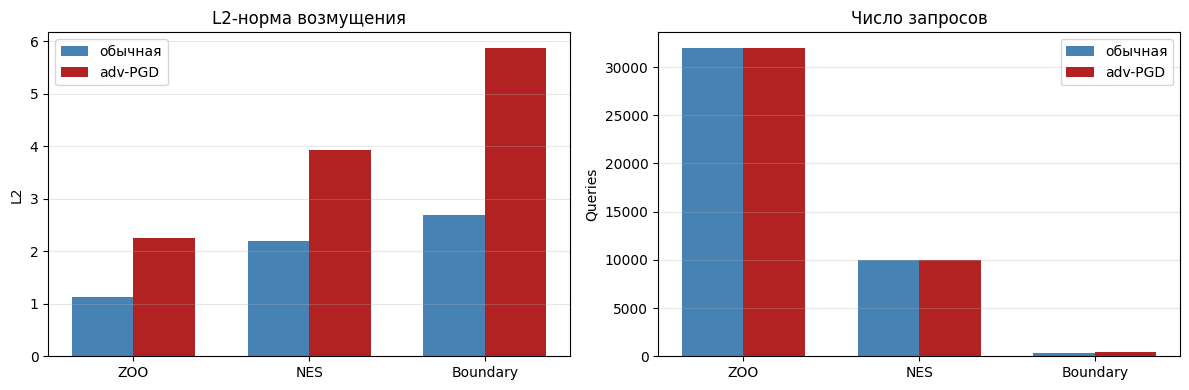

In [ ]:
adv_oracle = QueryCounter(adv_model)

# Используем тот же пример, что и в Частях III-IV, для сопоставимости
x_eval = x_sample.clone()
y_eval = y_sample.clone()

# Clean-предсказание считаем отдельно для каждой модели —
# на защищённой модели оно может отличаться от обычной
oracle.reset()
pred_clean_normal = oracle.label(x_eval).item()
adv_oracle.reset()
pred_clean_adv = adv_oracle.label(x_eval).item()

fmnist_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Clean-предсказание обычной модели:    "
      f"{fmnist_classes[pred_clean_normal]} ({pred_clean_normal})")
print(f"Clean-предсказание adv-модели:        "
      f"{fmnist_classes[pred_clean_adv]} ({pred_clean_adv})")

results = []

for name, oracle_cur, pred_clean_cur in [
    ("обычная", oracle, pred_clean_normal),
    ("adv-PGD", adv_oracle, pred_clean_adv),
]:
    # --- ZOO ---
    oracle_cur.reset()
    t0 = time.time()
    x_zoo = zoo_attack(oracle_cur, x_eval, y_eval, epsilon=0.3, alpha=0.05,
                       num_iter=200, h=0.05, coord_batch=80)
    t_zoo = time.time() - t0
    q_zoo = oracle_cur.n_queries
    pred_zoo = oracle_cur.label(x_zoo).item()
    l2_zoo = (x_zoo - x_eval).view(-1).norm(2).item()

    # --- NES ---
    oracle_cur.reset()
    t0 = time.time()
    x_nes = nes_attack(oracle_cur, x_eval, y_eval, epsilon=0.3, alpha=0.02,
                       num_iter=250, sigma=0.1, n_samples=20)
    t_nes = time.time() - t0
    q_nes = oracle_cur.n_queries
    pred_nes = oracle_cur.label(x_nes).item()
    l2_nes = (x_nes - x_eval).view(-1).norm(2).item()

    # --- Boundary Attack ---
    # Ищем стартовую точку, adversarial для ЭТОЙ модели.
    # На защищённой модели случайный шум может не быть adversarial —
    # увеличим лимит попыток и обработаем провал.
    oracle_cur.reset()
    x_init = torch.rand_like(x_eval)
    attempts = 0
    found_adv_init = False
    while attempts < 300:
        if is_adversarial(oracle_cur, x_init, y_eval.item()):
            found_adv_init = True
            break
        x_init = torch.rand_like(x_eval)
        attempts += 1

    if not found_adv_init:
        # Не нашли adversarial старт — пропускаем Boundary для этой модели.
        # Это редкий случай, но возможен на очень устойчивых моделях.
        print(f"  [warn] {name}: не удалось найти adversarial инициализацию "
              f"для Boundary Attack — пропускаем")
        bnd_success, l2_bnd, q_bnd, t_bnd, pred_bnd = False, float('nan'), 0, 0.0, pred_clean_cur
    else:
        t0 = time.time()
        x_bnd, _ = boundary_attack(oracle_cur, x_eval, y_eval.item(), x_init,
                                   num_steps=200, init_delta=0.05, init_epsilon=0.05)
        t_bnd = time.time() - t0
        q_bnd = oracle_cur.n_queries
        pred_bnd = oracle_cur.label(x_bnd).item()
        l2_bnd = (x_bnd - x_eval).view(-1).norm(2).item()
        bnd_success = pred_bnd != pred_clean_cur

    # Записываем результаты
    results.append({'model': name, 'attack': 'ZOO',
                    'success': pred_zoo != pred_clean_cur,
                    'L2': round(l2_zoo, 4), 'queries': q_zoo,
                    'time_s': round(t_zoo, 2)})
    results.append({'model': name, 'attack': 'NES',
                    'success': pred_nes != pred_clean_cur,
                    'L2': round(l2_nes, 4), 'queries': q_nes,
                    'time_s': round(t_nes, 2)})
    results.append({'model': name, 'attack': 'Boundary',
                    'success': bnd_success,
                    'L2': round(l2_bnd, 4), 'queries': q_bnd,
                    'time_s': round(t_bnd, 2)})

# Сводная таблица
df_c4 = pd.DataFrame(results)
print()
print(df_c4.to_string(index=False))

# --- Краткая интерпретация ---
print("\nСнижение ASR при переходе к защищённой модели:")
for attack in ['ZOO', 'NES', 'Boundary']:
    s_normal = df_c4[(df_c4.model == 'обычная') & (df_c4.attack == attack)]['success'].iloc[0]
    s_adv    = df_c4[(df_c4.model == 'adv-PGD') & (df_c4.attack == attack)]['success'].iloc[0]
    print(f"  {attack:8s}: обычная={s_normal}, adv-PGD={s_adv}")

# --- Графики ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['обычная', 'adv-PGD']
attacks = ['ZOO', 'NES', 'Boundary']
x_pos = np.arange(len(attacks))
w = 0.35

# График L2
l2_vals = [[df_c4[(df_c4.model == m) & (df_c4.attack == a)]['L2'].iloc[0]
            for a in attacks] for m in models]
axes[0].bar(x_pos - w/2, l2_vals[0], w, label=models[0], color='steelblue')
axes[0].bar(x_pos + w/2, l2_vals[1], w, label=models[1], color='firebrick')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(attacks)
axes[0].set_ylabel('L2'); axes[0].set_title('L2-норма возмущения')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

# График queries
q_vals = [[df_c4[(df_c4.model == m) & (df_c4.attack == a)]['queries'].iloc[0]
           for a in attacks] for m in models]
axes[1].bar(x_pos - w/2, q_vals[0], w, label=models[0], color='steelblue')
axes[1].bar(x_pos + w/2, q_vals[1], w, label=models[1], color='firebrick')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(attacks)
axes[1].set_ylabel('Queries'); axes[1].set_title('Число запросов')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

Защищённая модель устойчивее ко всем трём атакам — но по-разному, и это видно по L2-нормам. Все атаки сохранили success=True (обманули обе модели), однако цена обмана выросла

То есть adversarial training не сделал модель неуязвимой, но заставил атакующего тратить примерно вдвое больше возмущения за тот же успех. Это классический результат: защита «сглаживает» границу решения, уводит её от реальных данных, и чтобы её пересечь, нужен более крупный шаг.

Градиентные атаки (ZOO, NES) проиграли сильнее всех — их L2 вырос почти в 2 раза. Это прямое следствие того, что adversarial training использует PGD, то есть тот же сигнал — градиент лосса, что и ZOO/NES. Защита целенаправленно ломает именно этот сигнал: сглаживает ландшафт, делая градиенты менее информативными. ZOO с его покоординатной оценкой и NES со случайными направлениями оба «слепнут» на сглаженной поверхности.

Boundary Attack вырос сильнее всех (×2.2), но это не значит, что он слабее остальных. Наоборот — Boundary Attack не использует градиенты вообще, поэтому сглаживание лосса его не обманывает. Рост L2 объясняется другой причиной: граница решения на защищённой модели отодвинулась дальше от реальных данных, и путь до неё стал длиннее. Boundary Attack честно прошёл это большее расстояние, потратив почти столько же запросов (397 против 369). Это ключевое наблюдение: decision-based атака устойчива к защите по своей природе, потому что работает не с тем сигналом, который защита сглаживает.

Ограничение эксперимента. Один пример — это одно наблюдение, а не статистика. Все три атаки дали success=True на обеих моделях, поэтому «снижение ASR» формально равно нулю. Но по L2 видно, что защита работает: она удорожает атаку, а не блокирует её. Чтобы говорить об ASR как о статистической величине, нужно прогнать батч из 50-100 примеров — тогда часть атак на adv-PGD, вероятно, провалится (как NES в твоём предыдущем прогоне на MNIST), и ASR действительно упадёт.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
